# Question 2: Differential-Drive Simulation

### Discrete Time Kinematic Model
$$ p_{\text{new}} = p_{\text{old}} + \dot{p} \Delta t $$
where,
$$ \dot{p} = \begin{bmatrix} \dot{x} \\ \dot{y} \\ \dot{\theta} \end{bmatrix} = \begin{bmatrix} \cos\theta & 0 \\ \sin\theta & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} v \\ \omega \end{bmatrix} $$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def simulate(v, w, time_epoch=0.1, duration=30.0):
    v_func = v if callable(v) else (lambda t: float(v))
    w_func = w if callable(w) else (lambda t: float(w))

    t = np.arange(0, duration + time_epoch, time_epoch)
    n = len(t)
    
    x = np.zeros(n)
    y = np.zeros(n)
    theta = np.zeros(n)

    # Initial pose at origin with zero angle
    x[0] = 0.0
    y[0] = 0.0
    theta[0] = 0.0

    for i in range(n - 1):
        t_i = t[i]
        v_i = v_func(t_i)
        w_i = w_func(t_i)

        x_dot = v_i * np.cos(theta[i])
        y_dot = v_i * np.sin(theta[i])
        theta_dot = w_i

        if abs(x_dot) < 1e-10:
            x_dot = 0.0
        if abs(y_dot) < 1e-10:
            y_dot = 0.0
        if abs(theta_dot) < 1e-10:
            theta_dot = 0.0

        x[i + 1] = x[i] + x_dot * time_epoch
        y[i + 1] = y[i] + y_dot * time_epoch
        theta[i + 1] = theta[i] + theta_dot * time_epoch

    x[np.abs(x) < 1e-10] = 0.0
    y[np.abs(y) < 1e-10] = 0.0
    theta[np.abs(theta) < 1e-10] = 0.0

    return t, x, y, theta

def plot_case(t, x, y, theta, case_title):
    """Plot the 2D trajectory and state variables.
    Citation: LLM used to help write this matplotlib function.
    """
    fig = plt.figure(figsize=(13, 6))
    gs = gridspec.GridSpec(3, 2, figure=fig, width_ratios=[1.2, 1])

    # 1. Top-view 2D trajectory (x vs y)
    ax_traj = fig.add_subplot(gs[:, 0])
    ax_traj.plot(x, y, 'b-', linewidth=2, label='Trajectory')
    ax_traj.plot(x[0], y[0], 'go', markersize=8, label='Start (0, 0)')
    ax_traj.plot(x[-1], y[-1], 'ro', markersize=8, label=f'End ({x[-1]:.2f}, {y[-1]:.2f})')
    ax_traj.set_xlabel('x [m]', fontsize=11)
    ax_traj.set_ylabel('y [m]', fontsize=11)
    ax_traj.set_title(f'2D Trajectory: {case_title}', fontsize=12, fontweight='bold')
    ax_traj.axis('equal')
    ax_traj.grid(True, linestyle='--', alpha=0.6)
    ax_traj.legend(loc='best')

    # 2. x(t) vs time
    ax_x = fig.add_subplot(gs[0, 1])
    ax_x.plot(t, x, 'tab:blue', linewidth=1.5)
    ax_x.set_ylabel('x [m]', fontsize=10)
    ax_x.set_title('State Variables vs Time', fontsize=12, fontweight='bold')
    ax_x.grid(True, linestyle='--', alpha=0.6)

    # 3. y(t) vs time
    ax_y = fig.add_subplot(gs[1, 1], sharex=ax_x)
    ax_y.plot(t, y, 'tab:orange', linewidth=1.5)
    ax_y.set_ylabel('y [m]', fontsize=10)
    ax_y.grid(True, linestyle='--', alpha=0.6)

    # 4. theta(t) vs time
    ax_th = fig.add_subplot(gs[2, 1], sharex=ax_x)
    ax_th.plot(t, theta, 'tab:green', linewidth=1.5)
    ax_th.set_xlabel('Time t [s]', fontsize=11)
    ax_th.set_ylabel(r'$\theta$ [rad]', fontsize=10)
    ax_th.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


### Case 1: $[v, \omega]^\top = [1, 0]^\top$

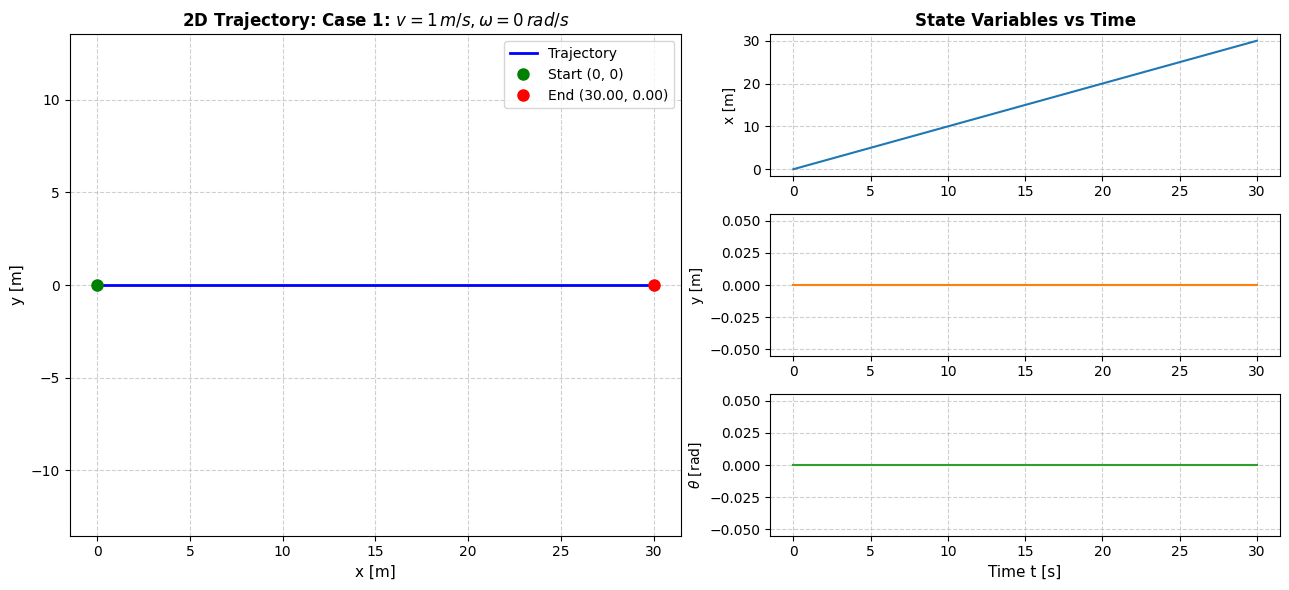

In [10]:
t, x, y, theta = simulate(v=1.0, w=0.0, time_epoch=0.1, duration=30.0)
plot_case(t, x, y, theta, r'Case 1: $v=1\,m/s, \omega=0\,rad/s$')

### Case 2: $[v, \omega]^\top = [0, 0.5]^\top$ 

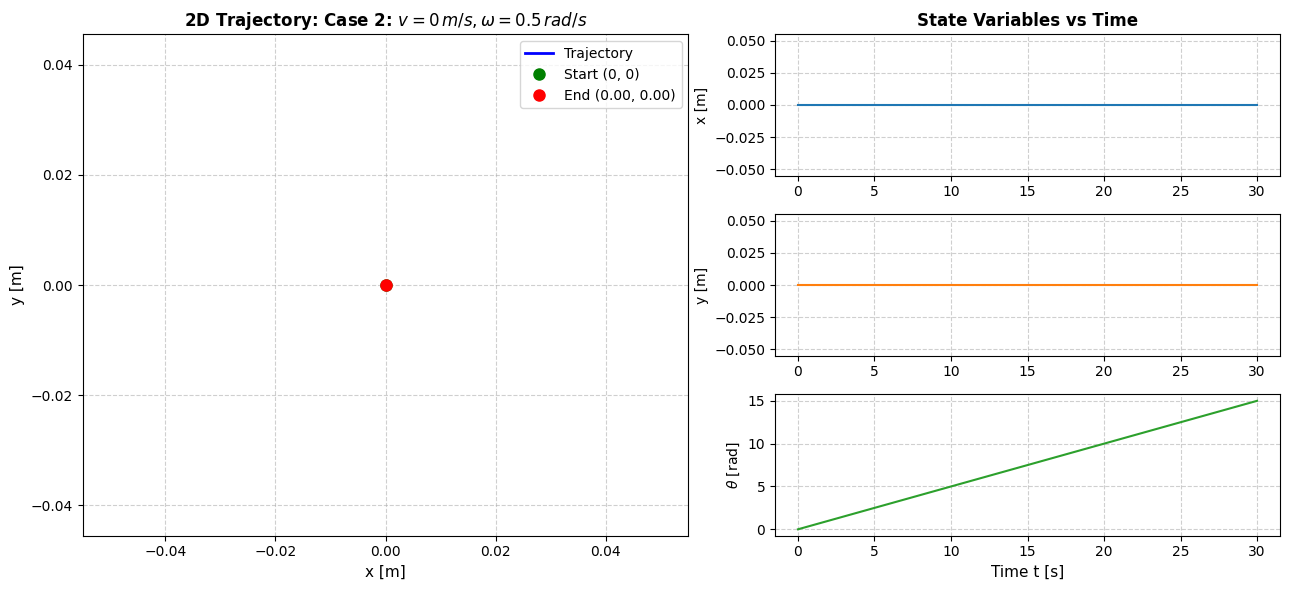

In [11]:
t, x, y, theta = simulate(v=0.0, w=0.5, time_epoch=0.1, duration=30.0)
plot_case(t, x, y, theta, r'Case 2: $v=0\,m/s, \omega=0.5\,rad/s$')

### Case 3: $[v, \omega]^\top = [1, 0.5]^\top$

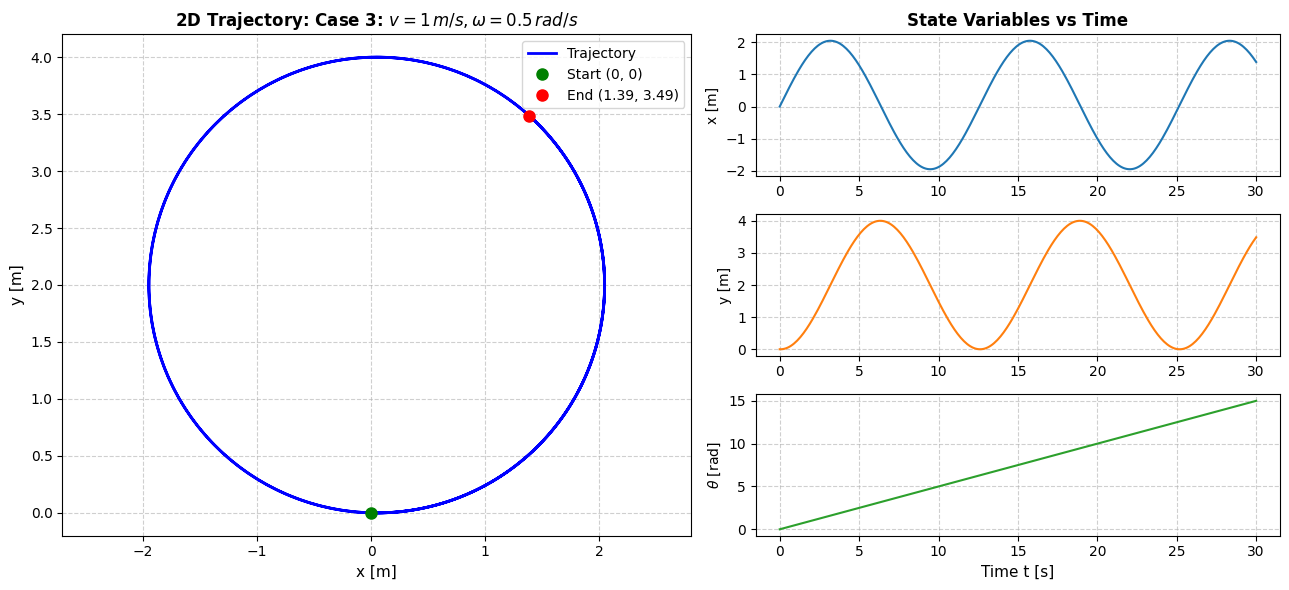

In [12]:
t, x, y, theta = simulate(v=1.0, w=0.5, time_epoch=0.1, duration=30.0)
plot_case(t, x, y, theta, r'Case 3: $v=1\,m/s, \omega=0.5\,rad/s$')

### Case 4: Velocity Profiles: $v(t) = 1 + 0.2\sin(t), \quad \omega(t) = 0.2 + 0.6\cos(t)$

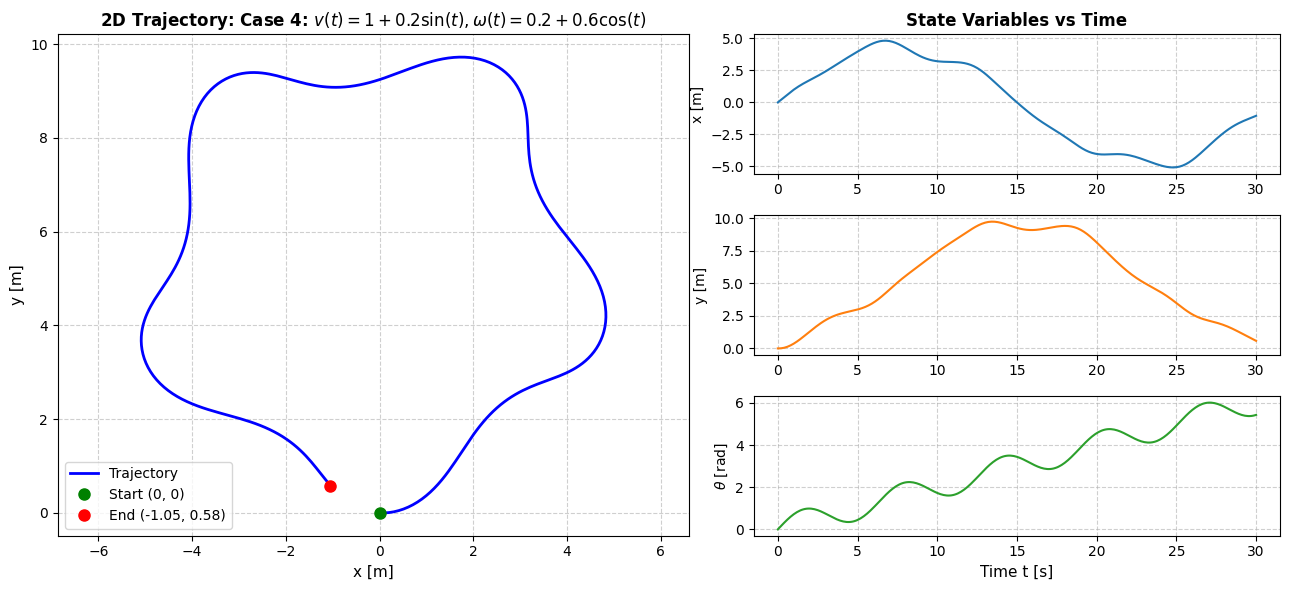

In [13]:
v_profile = lambda t: 1.0 + 0.2 * np.sin(t)
w_profile = lambda t: 0.2 + 0.6 * np.cos(t)
t, x, y, theta = simulate(v=v_profile, w=w_profile, time_epoch=0.1, duration=30.0)
plot_case(t, x, y, theta, r'Case 4: $v(t)=1+0.2\sin(t), \omega(t)=0.2+0.6\cos(t)$')